In [6]:
# Phase 0: Imports and global configuration
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)

DATA_DIR = Path("dataset")
TRAIN_PATH = DATA_DIR / "train.parquet"
TEST_PATH = DATA_DIR / "test.parquet"

print("Train path:", TRAIN_PATH.resolve())
print("Test path:", TEST_PATH.resolve())

Train path: /home/sg/dev/nlp/dataset/train.parquet
Test path: /home/sg/dev/nlp/dataset/test.parquet


In [7]:
# Phase 1: Load CoNLL-2000 parquet files
def read_parquet_safe(path):
    # Prefer fastparquet to avoid pyarrow extension registration conflicts in some envs.
    for engine in ("fastparquet", "pyarrow"):
        try:
            return pd.read_parquet(path, engine=engine)
        except Exception as exc:
            last_error = exc
    raise RuntimeError(f"Could not read {path} with fastparquet or pyarrow: {last_error}")

train_df = read_parquet_safe(TRAIN_PATH)
test_df = read_parquet_safe(TEST_PATH)

print("train shape:", train_df.shape)
print("test shape:", test_df.shape)
print("columns:", train_df.columns.tolist())

required_cols = {"id", "tokens", "pos_tags", "chunk_tags"}
missing = required_cols - set(train_df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Quick schema sanity check
assert train_df["tokens"].map(len).equals(train_df["chunk_tags"].map(len)), "tokens/chunk_tags length mismatch in train"
assert test_df["tokens"].map(len).equals(test_df["chunk_tags"].map(len)), "tokens/chunk_tags length mismatch in test"

train_df.head(2)

train shape: (8937, 4)
test shape: (2013, 4)
columns: ['id', 'tokens', 'pos_tags', 'chunk_tags']


,id,tokens,pos_tags,chunk_tags
0,0,"[Confidence, in, the, pound, is, widely, expected, to, take, another, sharp, dive, if, trade, figures, for, Septembe...","[19, 14, 11, 19, 39, 27, 37, 32, 34, 11, 15, 19, 14, 19, 22, 14, 20, 5, 15, 14, 19, 19, 5, 34, 32, 34, 11, 15, 19, 1...","[11, 13, 11, 12, 21, 22, 22, 22, 22, 11, 12, 12, 17, 11, 12, 13, 11, 0, 1, 13, 11, 11, 0, 21, 22, 22, 11, 12, 12, 13..."
1,1,"[Chancellor, of, the, Exchequer, Nigel, Lawson, 's, restated, commitment, to, a, firm, monetary, policy, has, helped...","[20, 14, 11, 20, 20, 20, 24, 37, 19, 32, 11, 19, 15, 19, 39, 37, 32, 34, 11, 19, 14, 19, 14, 11, 15, 19, 6]","[0, 13, 11, 12, 11, 12, 11, 12, 12, 13, 11, 12, 12, 12, 21, 22, 22, 22, 11, 12, 13, 11, 13, 11, 12, 12, 0]"


In [8]:
# Phase 2: Decode label IDs to human-readable POS and chunk tags
POS_LABELS = [
    "''", "#", "$", "(", ")", ",", ".", ":", "CC", "CD", "DT", "EX", "FW", "IN", "JJ", "JJR", "JJS", "LS",
    "MD", "NN", "NNP", "NNPS", "NNS", "NN|SYM", "PDT", "POS", "PRP", "PRP$", "RB", "RBR", "RBS", "RP", "SYM",
    "TO", "UH", "VB", "VBD", "VBG", "VBN", "VBP", "VBZ", "WDT", "WP", "WP$", "WRB"
 ]

# CoNLL-2000 chunk labels in the standard order used by many HF exports
CHUNK_LABELS = [
    "O", "B-ADJP", "I-ADJP", "B-ADVP", "I-ADVP", "B-CONJP", "I-CONJP", "B-INTJ", "I-INTJ", "B-LST",
    "I-LST", "B-NP", "I-NP", "B-PP", "I-PP", "B-PRT", "I-PRT", "B-SBAR", "I-SBAR", "B-UCP", "I-UCP",
    "B-VP", "I-VP"
]

def decode_ids(id_list, label_list):
    out = []
    for idx in id_list:
        idx = int(idx)
        out.append(label_list[idx] if 0 <= idx < len(label_list) else f"UNK_{idx}")
    return out

train_df = train_df.copy()
test_df = test_df.copy()
train_df["pos_labels"] = train_df["pos_tags"].apply(lambda x: decode_ids(x, POS_LABELS))
test_df["pos_labels"] = test_df["pos_tags"].apply(lambda x: decode_ids(x, POS_LABELS))
train_df["chunk_labels"] = train_df["chunk_tags"].apply(lambda x: decode_ids(x, CHUNK_LABELS))
test_df["chunk_labels"] = test_df["chunk_tags"].apply(lambda x: decode_ids(x, CHUNK_LABELS))

sample = train_df.iloc[0]
pd.DataFrame({
    "token": sample["tokens"],
    "pos": sample["pos_labels"],
    "chunk": sample["chunk_labels"]
}).head(20)

,token,pos,chunk
0,Confidence,NN,B-NP
1,in,JJ,B-PP
2,the,EX,B-NP
3,pound,NN,I-NP
4,is,VBP,B-VP
5,widely,PRP$,I-VP
6,expected,VBG,I-VP
7,to,SYM,I-VP
8,take,UH,I-VP
9,another,EX,B-NP


In [9]:
# Phase 3: Exploratory analysis
from collections import Counter

train_lengths = train_df["tokens"].map(len)
test_lengths = test_df["tokens"].map(len)

print("Train sentence length stats:")
print(train_lengths.describe(percentiles=[0.5, 0.9, 0.95, 0.99]))
print("\nTest sentence length stats:")
print(test_lengths.describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

chunk_counter = Counter()
for seq in train_df["chunk_labels"]:
    chunk_counter.update(seq)

chunk_freq = (
    pd.DataFrame(chunk_counter.items(), columns=["chunk_tag", "count"])
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
 )
chunk_freq.head(20)

Train sentence length stats:
count    8937.000000
mean       23.691060
std        11.149961
min         0.000000
50%        23.000000
90%        39.000000
95%        44.000000
99%        54.000000
max        78.000000
Name: tokens, dtype: float64

Test sentence length stats:
count    2013.000000
mean       23.535519
std        10.821494
min         0.000000
50%        23.000000
90%        38.000000
95%        42.000000
99%        53.000000
max        70.000000
Name: tokens, dtype: float64


,chunk_tag,count
0,I-NP,63307
1,B-NP,55081
2,O,27902
3,B-VP,21467
4,B-PP,21281
5,I-VP,12003
6,B-ADVP,4227
7,B-SBAR,2207
8,B-ADJP,2060
9,I-ADJP,643


In [10]:
# Phase 4: POS-only baseline with scikit-learn
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score

def sentence_to_features(tokens, pos_ids, i):
    prev_pos = int(pos_ids[i - 1]) if i > 0 else -1
    next_pos = int(pos_ids[i + 1]) if i < len(pos_ids) - 1 else -1
    return {
        "token": tokens[i].lower(),
        "pos": int(pos_ids[i]),
        "prev_pos": prev_pos,
        "next_pos": next_pos,
        "is_upper": tokens[i].isupper(),
        "is_title": tokens[i].istitle(),
        "is_digit": tokens[i].isdigit(),
    }

def to_python_scalars(obj):
    if isinstance(obj, dict):
        return {k: to_python_scalars(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_python_scalars(v) for v in obj]
    if hasattr(obj, "item"):
        try:
            return obj.item()
        except Exception:
            return obj
    return obj

X_train_dict, y_train = [], []
for _, row in train_df.iterrows():
    tokens, pos_ids, chunk_ids = row["tokens"], row["pos_tags"], row["chunk_tags"]
    for i in range(len(tokens)):
        X_train_dict.append(sentence_to_features(tokens, pos_ids, i))
        y_train.append(int(chunk_ids[i]))

X_test_dict, y_test = [], []
for _, row in test_df.iterrows():
    tokens, pos_ids, chunk_ids = row["tokens"], row["pos_tags"], row["chunk_tags"]
    for i in range(len(tokens)):
        X_test_dict.append(sentence_to_features(tokens, pos_ids, i))
        y_test.append(int(chunk_ids[i]))

vectorizer = DictVectorizer(sparse=True)
X_train = vectorizer.fit_transform(X_train_dict)
X_test = vectorizer.transform(X_test_dict)

# sklearn>=1.8 removed the `multi_class` argument from LogisticRegression.
clf = LogisticRegression(max_iter=300, n_jobs=-1)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")
print(f"Token-level macro F1: {macro_f1:.4f}")
print(f"Token-level weighted F1: {weighted_f1:.4f}")

print("\nPer-label report (token level):")
print(classification_report(y_test, y_pred, zero_division=0))

# Convert predictions back to string labels for optional chunk-level seqeval
pred_label_sequences = []
true_label_sequences = []
cursor = 0
for _, row in test_df.iterrows():
    n = len(row["tokens"])
    pred_ids_seq = y_pred[cursor: cursor + n]
    true_ids_seq = y_test[cursor: cursor + n]
    pred_label_sequences.append([CHUNK_LABELS[int(x)] for x in pred_ids_seq])
    true_label_sequences.append([CHUNK_LABELS[int(x)] for x in true_ids_seq])
    cursor += n

try:
    import evaluate
    seqeval = evaluate.load("seqeval")
    seqeval_scores = seqeval.compute(predictions=pred_label_sequences, references=true_label_sequences)
    print("\nSeqeval (chunk-level):")
    print(json.dumps(to_python_scalars(seqeval_scores), indent=2))
except Exception as e:
    print("\nSeqeval not available. Install evaluate and seqeval for chunk-level F1.")
    print("Reason:", str(e))

Token-level macro F1: 0.2678
Token-level weighted F1: 0.7293

Per-label report (token level):
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      6180
           1       0.00      0.00      0.00       438
           2       0.00      0.00      0.00       167
           3       0.95      0.08      0.15       866
           4       0.00      0.00      0.00        89
           5       0.00      0.00      0.00         9
           6       0.00      0.00      0.00        13
           7       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         5
          10       0.00      0.00      0.00         2
          11       0.80      0.56      0.66     12422
          12       0.62      0.86      0.72     14376
          13       0.95      0.83      0.89      4811
          14       0.00      0.00      0.00        48
          15       0.00      0.00      0.00       106
          17       0.72      0.12      0.

## Phase 5: Modern Transformer Pipeline (Recommended)

This section implements a current token-classification recipe for chunking.

Install first (in your environment):
- transformers
- datasets
- evaluate
- seqeval
- torch
- accelerate (required by Trainer)

In [11]:
# Phase 5a: Dependency guard
missing = []
for pkg, import_name in [
    ("datasets", "datasets"),
    ("transformers", "transformers"),
    ("evaluate", "evaluate"),
    ("seqeval", "seqeval"),
    ("torch", "torch"),
    ("accelerate", "accelerate"),
]:
    try:
        __import__(import_name)
    except Exception:
        missing.append(pkg)

if missing:
    print("Missing packages:", missing)
    print("Install them before running transformer training.")
    print("Suggested command: uv add " + " ".join(missing))
else:
    print("All transformer dependencies are available.")

All transformer dependencies are available.


In [12]:
# Phase 5b: Build Hugging Face datasets from the loaded dataframe
from datasets import Dataset, DatasetDict

def to_hf_df(df):
    return pd.DataFrame({
        "id": df["id"].astype(str),
        "tokens": df["tokens"],
        "chunk_tags": df["chunk_tags"],
    })

hf_datasets = DatasetDict({
    "train": Dataset.from_pandas(to_hf_df(train_df), preserve_index=False),
    "test": Dataset.from_pandas(to_hf_df(test_df), preserve_index=False),
})

hf_datasets

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'chunk_tags'],
        num_rows: 8937
    })
    test: Dataset({
        features: ['id', 'tokens', 'chunk_tags'],
        num_rows: 2013
    })
})

In [13]:
# Phase 5c: Tokenization + label alignment
import numpy as np
from transformers import AutoTokenizer

MODEL_CHECKPOINT = "distilbert/distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

label_list = CHUNK_LABELS
id2label = {i: v for i, v in enumerate(label_list)}
label2id = {v: i for i, v in enumerate(label_list)}

def tokenize_and_align_labels(examples):
    tokenized = tokenizer(examples["tokens"], truncation=True, is_split_into_words=True)
    labels = []
    for i, label_seq in enumerate(examples["chunk_tags"]):
        word_ids = tokenized.word_ids(batch_index=i)
        prev = None
        aligned = []
        for word_idx in word_ids:
            if word_idx is None:
                aligned.append(-100)
            elif word_idx != prev:
                aligned.append(int(label_seq[word_idx]))
            else:
                aligned.append(-100)
            prev = word_idx
        labels.append(aligned)
    tokenized["labels"] = labels
    return tokenized

tokenized_ds = hf_datasets.map(tokenize_and_align_labels, batched=True)
tokenized_ds

Map: 100%|██████████| 2013/2013 [00:00<00:00, 14106.99 examples/s]


DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'chunk_tags', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 8937
    })
    test: Dataset({
        features: ['id', 'tokens', 'chunk_tags', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 2013
    })
})

In [14]:
# Phase 5d: Trainer setup + metrics
import inspect
import evaluate
from transformers import (
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    TrainingArguments,
    Trainer,
 )

try:
    import accelerate
except Exception as e:
    raise ImportError(
        "Missing dependency: accelerate. Install with `uv add 'accelerate>=1.1.0'` "
        "(or `pip install 'accelerate>=1.1.0'`) and re-run from Cell 7."
    ) from e

# Compatibility shim for older accelerate versions that do not support
# `keep_torch_compile` in `Accelerator.unwrap_model`.
if "keep_torch_compile" not in inspect.signature(accelerate.Accelerator.unwrap_model).parameters:
    _orig_unwrap_model = accelerate.Accelerator.unwrap_model

    def _unwrap_model_compat(self, model, keep_torch_compile=None):
        return _orig_unwrap_model(self, model)

    accelerate.Accelerator.unwrap_model = _unwrap_model_compat
    print("Applied accelerate compatibility patch for unwrap_model().")

seqeval = evaluate.load("seqeval")
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=2)

    true_preds, true_labels = [], []
    for pred_seq, label_seq in zip(preds, labels):
        p_seq, l_seq = [], []
        for p, l in zip(pred_seq, label_seq):
            if l != -100:
                p_seq.append(label_list[int(p)])
                l_seq.append(label_list[int(l)])
        true_preds.append(p_seq)
        true_labels.append(l_seq)

    out = seqeval.compute(predictions=true_preds, references=true_labels)
    return {
        "precision": out["overall_precision"],
        "recall": out["overall_recall"],
        "f1": out["overall_f1"],
        "accuracy": out["overall_accuracy"],
    }

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id,
 )

training_args = TrainingArguments(
    output_dir="outputs/distilbert-conll2000",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none",
 )

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["test"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
 )

print("Trainer is ready. Run: trainer.train()")

Applied accelerate compatibility patch for unwrap_model().


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3058.10it/s]
DistilBertForTokenClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainer is ready. Run: trainer.train()


In [15]:
# Phase 5e: Train + final evaluation
from transformers.utils.notebook import NotebookProgressCallback

# Workaround for a known notebook callback state issue in some transformers versions.
try:
    trainer.remove_callback(NotebookProgressCallback)
except Exception:
    pass

if trainer.state.global_step == 0:
    trainer.train()
else:
    print(f"Skipping train(): existing global_step={trainer.state.global_step}")

final_metrics = trainer.evaluate()
final_metrics

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.90it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


{'eval_loss': 0.10520093142986298,
 'eval_precision': 0.9564999791466823,
 'eval_recall': 0.961512661412041,
 'eval_f1': 0.9589997700140083,
 'eval_accuracy': 0.9742280009287206,
 'eval_runtime': 3.806,
 'eval_samples_per_second': 528.897,
 'eval_steps_per_second': 33.105,
 'epoch': 3.0}

In [16]:
# Phase 6: Error analysis utilities
def flatten_chunk_sequences(df, col_name):
    return [tag for seq in df[col_name] for tag in seq]

# Baseline error analysis from Phase 4 predictions
baseline_true = [t for seq in true_label_sequences for t in seq]
baseline_pred = [p for seq in pred_label_sequences for p in seq]

baseline_errors = pd.DataFrame({
    "true": baseline_true,
    "pred": baseline_pred,
})
baseline_errors["is_error"] = baseline_errors["true"] != baseline_errors["pred"]

print("Baseline token error rate:", baseline_errors["is_error"].mean())
baseline_errors[baseline_errors["is_error"]].groupby(["true", "pred"]).size().sort_values(ascending=False).head(20)

Baseline token error rate: 0.25427950271228655


true    pred
B-NP    I-NP    4889
I-NP    B-NP    1291
I-VP    B-VP     566
B-PP    I-NP     526
B-ADVP  I-NP     478
B-VP    I-NP     443
I-NP    O        438
B-NP    B-VP     341
B-ADJP  I-NP     333
B-SBAR  I-NP     230
B-VP    I-VP     227
I-NP    B-VP     203
B-SBAR  B-NP     176
O       I-NP     161
B-ADVP  I-VP     142
B-NP    I-VP     132
I-ADJP  I-NP     127
B-PP    B-VP     115
B-ADVP  B-VP     115
B-PP    I-VP     104
dtype: int64

## Phase 7: Model Comparison and Visualization

This section compares the baseline model and transformer model on multiple metrics and plots visual summaries.

Run Cells 1 to 11 first, then run this section.

In [17]:
# Phase 7a: Build comparison tables (baseline vs transformer)
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

required = [
    "seqeval_scores",
    "final_metrics",
    "trainer",
    "tokenized_ds",
    "y_test",
    "y_pred",
    "label_list",
]
missing_vars = [name for name in required if name not in globals()]
if missing_vars:
    raise RuntimeError(
        "Run Cells 1 to 11 before this cell. Missing variables: " + ", ".join(missing_vars)
    )

# Baseline chunk-level metrics (seqeval)
baseline_chunk = {
    "precision": float(seqeval_scores["overall_precision"]),
    "recall": float(seqeval_scores["overall_recall"]),
    "f1": float(seqeval_scores["overall_f1"]),
    "accuracy": float(seqeval_scores["overall_accuracy"]),
}

# Transformer chunk-level metrics (from trainer.evaluate output)
transformer_chunk = {
    "precision": float(final_metrics["eval_precision"]),
    "recall": float(final_metrics["eval_recall"]),
    "f1": float(final_metrics["eval_f1"]),
    "accuracy": float(final_metrics["eval_accuracy"]),
}

comparison_chunk_df = pd.DataFrame([
    {"model": "Baseline (LogReg)", **baseline_chunk},
    {"model": "Transformer (DistilBERT)", **transformer_chunk},
]).set_index("model")

# Token-level metrics for baseline
b_prec, b_rec, b_f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average="macro", zero_division=0
)
b_prec_w, b_rec_w, b_f1_w, _ = precision_recall_fscore_support(
    y_test, y_pred, average="weighted", zero_division=0
)
baseline_token = {
    "accuracy": float(accuracy_score(y_test, y_pred)),
    "precision_macro": float(b_prec),
    "recall_macro": float(b_rec),
    "f1_macro": float(b_f1),
    "precision_weighted": float(b_prec_w),
    "recall_weighted": float(b_rec_w),
    "f1_weighted": float(b_f1_w),
}

# Token-level metrics for transformer via predictions on test set
pred_out = trainer.predict(tokenized_ds["test"])
logits = pred_out.predictions
labels = pred_out.label_ids
pred_ids = np.argmax(logits, axis=2)

t_true, t_pred = [], []
for pred_seq, label_seq in zip(pred_ids, labels):
    for p, l in zip(pred_seq, label_seq):
        if l != -100:
            t_true.append(int(l))
            t_pred.append(int(p))

t_prec, t_rec, t_f1, _ = precision_recall_fscore_support(
    t_true, t_pred, average="macro", zero_division=0
)
t_prec_w, t_rec_w, t_f1_w, _ = precision_recall_fscore_support(
    t_true, t_pred, average="weighted", zero_division=0
)
transformer_token = {
    "accuracy": float(accuracy_score(t_true, t_pred)),
    "precision_macro": float(t_prec),
    "recall_macro": float(t_rec),
    "f1_macro": float(t_f1),
    "precision_weighted": float(t_prec_w),
    "recall_weighted": float(t_rec_w),
    "f1_weighted": float(t_f1_w),
}

comparison_token_df = pd.DataFrame([
    {"model": "Baseline (LogReg)", **baseline_token},
    {"model": "Transformer (DistilBERT)", **transformer_token},
]).set_index("model")

# Per-label F1 comparison
labels_range = list(range(len(label_list)))
_, _, f1_base, support_base = precision_recall_fscore_support(
    y_test, y_pred, labels=labels_range, average=None, zero_division=0
)
_, _, f1_trans, support_trans = precision_recall_fscore_support(
    t_true, t_pred, labels=labels_range, average=None, zero_division=0
)

class_comparison_df = pd.DataFrame({
    "label_id": labels_range,
    "label": [label_list[i] for i in labels_range],
    "support_baseline": support_base,
    "support_transformer": support_trans,
    "f1_baseline": f1_base,
    "f1_transformer": f1_trans,
})
class_comparison_df["f1_gain"] = class_comparison_df["f1_transformer"] - class_comparison_df["f1_baseline"]

print("Chunk-level comparison:")
display(comparison_chunk_df.round(4))
print("\nToken-level comparison:")
display(comparison_token_df.round(4))
print("\nTop label gains (transformer - baseline):")
display(class_comparison_df.sort_values("f1_gain", ascending=False).head(10))

Chunk-level comparison:


,precision,recall,f1,accuracy
model,,,,
Baseline (LogReg),0.6562,0.6818,0.6688,0.7457
Transformer (DistilBERT),0.9565,0.9615,0.9590,0.9742



Token-level comparison:


,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
model,,,,,,,
Baseline (LogReg),0.7457,0.3386,0.2632,0.2678,0.7555,0.7457,0.7293
Transformer (DistilBERT),0.9742,0.7146,0.6840,0.6869,0.9741,0.9742,0.9741



Top label gains (transformer - baseline):


,label_id,label,support_baseline,support_transformer,f1_baseline,f1_transformer,f1_gain
1,1,B-ADJP,438,438,0.000000,0.821596,0.821596
15,15,B-PRT,106,106,0.000000,0.803493,0.803493
2,2,I-ADJP,167,167,0.000000,0.758170,0.758170
4,4,I-ADVP,89,89,0.000000,0.744186,0.744186
17,17,B-SBAR,535,535,0.208000,0.937615,0.729615
14,14,I-PP,48,48,0.000000,0.719101,0.719101
3,3,B-ADVP,866,866,0.146965,0.860935,0.713970
6,6,I-CONJP,13,13,0.000000,0.695652,0.695652
5,5,B-CONJP,9,9,0.000000,0.615385,0.615385
11,11,B-NP,12422,12422,0.661993,0.983018,0.321026


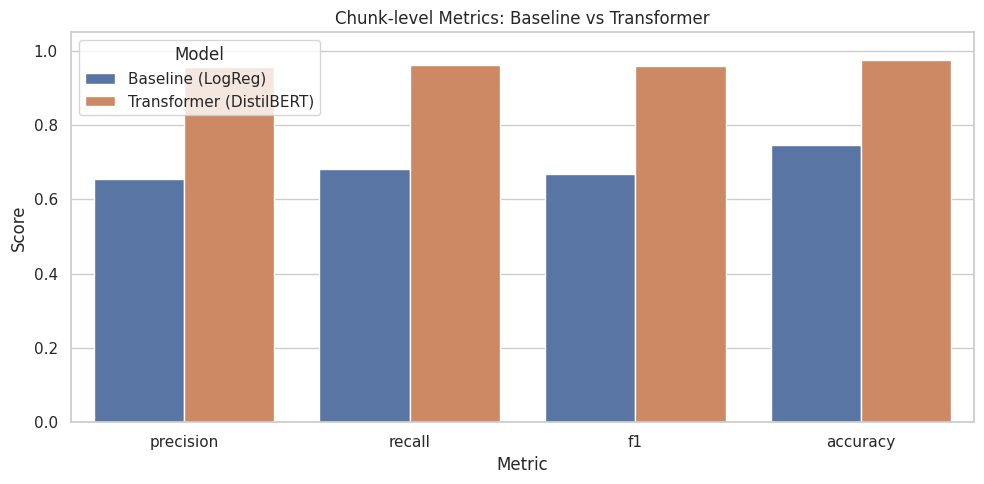

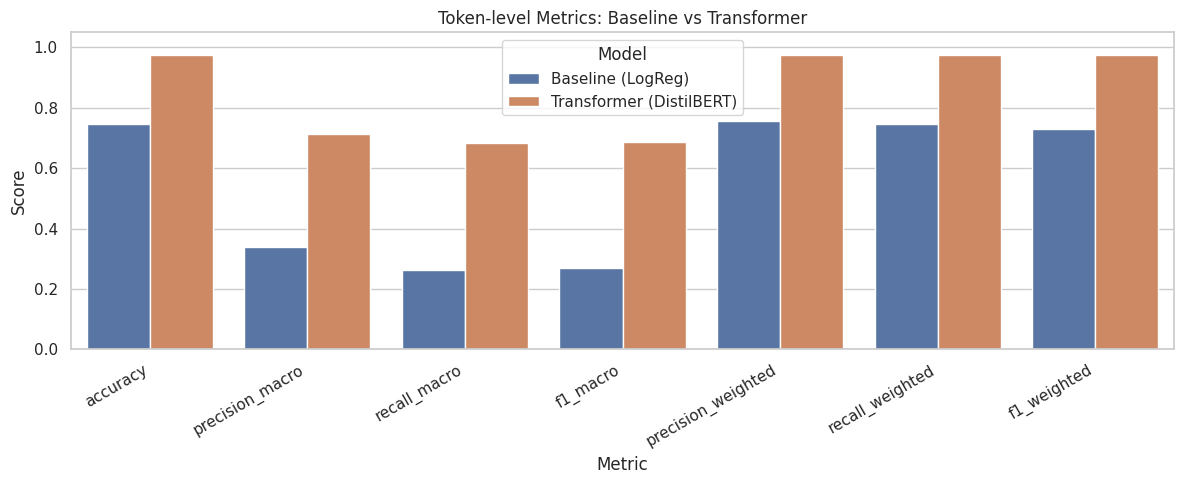

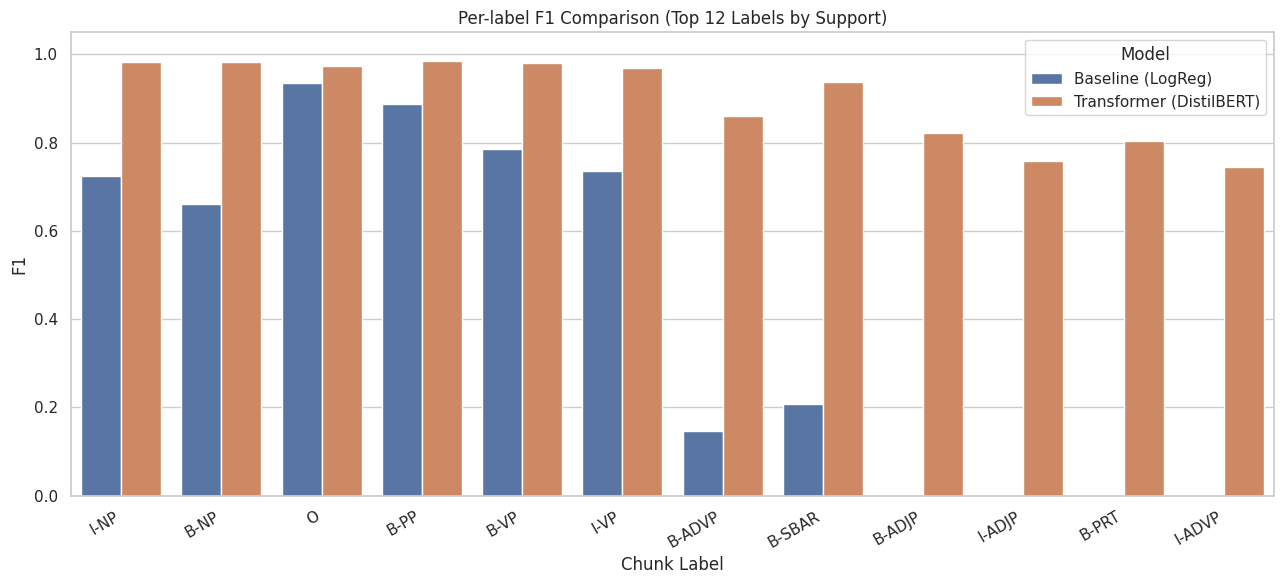

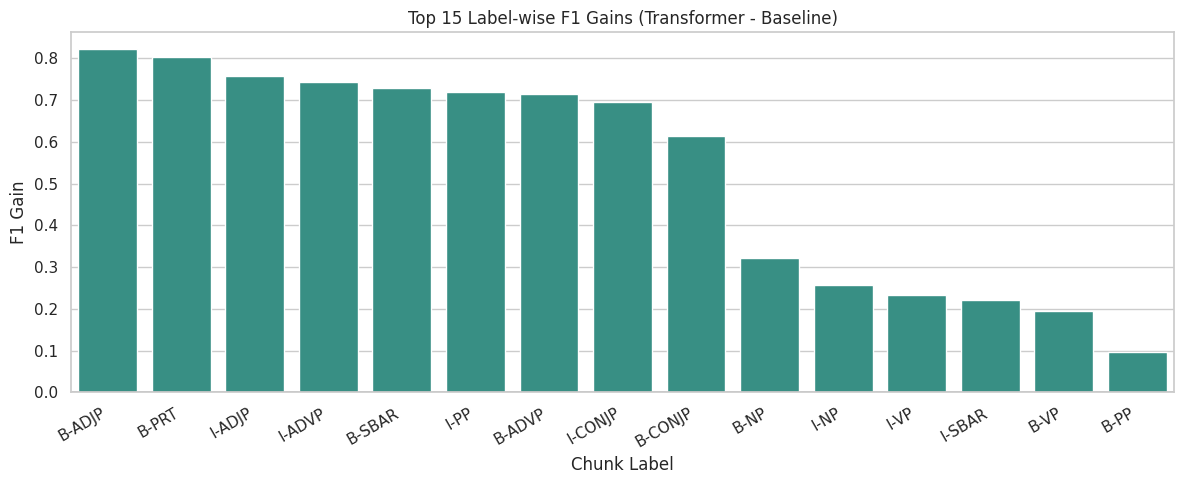

In [18]:
# Phase 7b: Visualize model comparison
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1) Chunk-level metrics comparison
chunk_plot_df = comparison_chunk_df.reset_index().melt(
    id_vars="model",
    value_vars=["precision", "recall", "f1", "accuracy"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(10, 5))
sns.barplot(data=chunk_plot_df, x="metric", y="score", hue="model")
plt.ylim(0, 1.05)
plt.title("Chunk-level Metrics: Baseline vs Transformer")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

# 2) Token-level metrics comparison
token_plot_df = comparison_token_df.reset_index().melt(
    id_vars="model",
    value_vars=[
        "accuracy", "precision_macro", "recall_macro", "f1_macro",
        "precision_weighted", "recall_weighted", "f1_weighted"
    ],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(12, 5))
sns.barplot(data=token_plot_df, x="metric", y="score", hue="model")
plt.ylim(0, 1.05)
plt.title("Token-level Metrics: Baseline vs Transformer")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

# 3) Per-label F1 comparison (top labels by support)
top_k = 12
top_labels_df = class_comparison_df.sort_values("support_baseline", ascending=False).head(top_k).copy()
top_labels_long = top_labels_df.melt(
    id_vars=["label", "support_baseline"],
    value_vars=["f1_baseline", "f1_transformer"],
    var_name="model",
    value_name="f1",
)
top_labels_long["model"] = top_labels_long["model"].map({
    "f1_baseline": "Baseline (LogReg)",
    "f1_transformer": "Transformer (DistilBERT)",
})

plt.figure(figsize=(13, 6))
sns.barplot(data=top_labels_long, x="label", y="f1", hue="model")
plt.ylim(0, 1.05)
plt.title(f"Per-label F1 Comparison (Top {top_k} Labels by Support)")
plt.ylabel("F1")
plt.xlabel("Chunk Label")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

# 4) F1 gain by label
gain_df = class_comparison_df.sort_values("f1_gain", ascending=False).head(15)
plt.figure(figsize=(12, 5))
sns.barplot(data=gain_df, x="label", y="f1_gain", color="#2a9d8f")
plt.axhline(0, color="black", linewidth=1)
plt.title("Top 15 Label-wise F1 Gains (Transformer - Baseline)")
plt.ylabel("F1 Gain")
plt.xlabel("Chunk Label")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()